# 07 — SPP1-TAM prevalence by treatment condition (single-cell)

*"How many SPP1-TAMs are there in each treatment arm?"* — the question 01c **cannot** answer, and
the single-cell counterpart to what 06 does spatially.

### Why this needs its own notebook
01c §4 splits macrophages into Spp1 terciles **within each sample**, which was the correct fix for
the treatment confound (per-cell Spp1 is 4-25x higher in NoTx, so a pooled split makes
"Spp1-high" partly mean "untreated"). But that split **normalises prevalence away by
construction**: every sample gets its own top-25% cut, so ~25% of macrophages are "high" in every
arm by definition.

The two questions need opposite tools:

| question | split | notebook |
|---|---|---|
| *What defines the SPP1-TAM state?* | **within-sample** (treatment-blind) | 01c §4 |
| *How many SPP1-TAMs are there?* | **global / absolute** cut | **this one** |

### Why this is not circular
The 48-gene signature was derived from a **within-sample** DE, so it never saw treatment as a
variable — it is a treatment-blind description of the cell state. Using it now to count cells per
arm is therefore a legitimate measurement. Had the signature been built on the globally-pooled
split, this analysis would be circular (the signature would encode "untreated" and we would be
rediscovering that).

### The metric that matters most
`frac_tam_high` = the fraction of **macrophages** that are SPP1-TAM-high. Because it is a
proportion *within* the macrophage compartment, it is **not affected by dissociation capture
bias** — unlike `mac_pct_of_cells`, which is. Read `frac_tam_high` and `mean_sig` as the robust
state metrics; read the abundance metrics with the capture-bias caveat attached.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

import scanpy as sc

from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80); pd.set_option("display.width", 240)

## 1. Config

In [2]:
SC_REF  = Path("/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/"
               "annotating_references/annotation_v4.h5ad")
OUT_DIR = Path("/coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis")
FIG_DIR = OUT_DIR / "figures"
SIG_CSV = OUT_DIR / "sc_spp1_tam_signature.csv"        # written by 01c §5
OUT_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_COL   = "file_name"
TUMOUR_LABEL = "Cancer_cell"
MAC_LABELS   = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]

# SINGLE-CELL arm names are CyTAG72 / RTCyTAG72 (the SPATIAL object spells them CyT72 / RTCyT72).
COND_META = {
    "NoTx":      {"RT": False, "cart": "none",        "cy": False},
    "CyTAG72":   {"RT": False, "cart": "nonspecific", "cy": True},
    "CyPSCA":    {"RT": False, "cart": "PSCA",        "cy": True},
    "RTCyTAG72": {"RT": True,  "cart": "nonspecific", "cy": True},
    "RTCyPSCA":  {"RT": True,  "cart": "PSCA",        "cy": True},
    # spatial aliases, harmless if absent here
    "CyT72":     {"RT": False, "cart": "nonspecific", "cy": True},
    "RTCyT72":   {"RT": True,  "cart": "nonspecific", "cy": True},
}
CONDITION_ORDER = ["NoTx", "CyTAG72", "CyPSCA", "RTCyTAG72", "RTCyPSCA"]

TAM_HIGH_Q  = 0.75     # GLOBAL cut: SPP1-TAM-high = top quartile of the signature across pooled macs
MIN_MACS    = 50       # per sample, below this the sample's fractions are unstable
STATE_METRICS = ["frac_tam_high", "mean_sig"]                       # capture-bias robust
ABUND_METRICS = ["mac_pct_of_cells", "tam_pct_of_cells"]            # capture-bias affected
METRICS = STATE_METRICS + ABUND_METRICS

assert SC_REF.exists(), f"reference not found: {SC_REF}"
print("config ready ->", OUT_DIR)

config ready -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis


## 2. Load, score the signature, build the design

In [3]:
scref = sc.read_h5ad(SC_REF)

lvl_cols = [c for c in scref.obs.columns if c.startswith("cell_type_lvl")]
want = set(MAC_LABELS) | {TUMOUR_LABEL}
CT_COL = max(lvl_cols, key=lambda c: len(set(scref.obs[c].astype(str)) & want))
sc_ct = scref.obs[CT_COL].astype(str)
print(f"cells: {scref.n_obs:,} | genes: {scref.n_vars:,} | using {CT_COL}")

X = scref.X
head = X[:200].toarray() if sp.issparse(X) else X[:200]
if bool(np.allclose(head, np.round(head))) and float(X.max()) > 50:
    scref.layers["counts"] = scref.X.copy()
    sc.pp.normalize_total(scref, target_sum=1e4); sc.pp.log1p(scref)
    print("normalized raw counts -> CP10K + log1p")
else:
    print(".X already log-normalized")

def expr_of(gene):
    v = scref[:, gene].X
    return np.asarray(v.todense()).ravel() if sp.issparse(v) else np.asarray(v).ravel()

sig_genes = pd.read_csv(SIG_CSV)["gene"].tolist()
present = [g for g in sig_genes if g in scref.var_names]
print(f"signature: {len(present)}/{len(sig_genes)} genes present")
if len(present) < len(sig_genes):
    print("  missing:", [g for g in sig_genes if g not in scref.var_names])
assert len(present) >= 8, "too few signature genes present"
sc.tl.score_genes(scref, gene_list=present, score_name="SPP1_TAM_sig", use_raw=False, random_state=0)
scref.obs["Spp1_expr"] = expr_of("Spp1")
scref.obs["is_mac"] = sc_ct.isin(MAC_LABELS).values
scref.obs["mac_subtype"] = np.where(scref.obs["is_mac"], sc_ct.values, "not_mac")

assert SAMPLE_COL in scref.obs.columns, f"{SAMPLE_COL} not in obs"
_p = scref.obs[SAMPLE_COL].astype(str).str.extract(
    r"^(?P<cond>.*)_Tu(?P<tumor_loc>\d+)_(?P<rep>\d+)$")
assert _p["cond"].notna().all(), "some file_name values do not match <cond>_Tu<loc>_<rep>"
scref.obs["cond"]      = _p["cond"].values
scref.obs["tumor_loc"] = _p["tumor_loc"].astype(int).values
scref.obs["rep"]       = _p["rep"].astype(int).values
scref.obs["sample"]    = scref.obs[SAMPLE_COL].astype(str).values
scref.obs["mouse"]     = scref.obs["cond"] + "_rep" + scref.obs["rep"].astype(str)
scref.obs["group"]     = scref.obs["cond"] + "_Tu" + scref.obs["tumor_loc"].astype(str)

unknown = sorted(set(scref.obs["cond"]) - set(COND_META))
if unknown:
    print(f"\n!! arms not in COND_META (no cart axis for them): {unknown}")
COND_PRESENT = [c for c in CONDITION_ORDER if c in set(scref.obs["cond"])] + unknown
GROUPS = [f"{c}_Tu{t}" for c in COND_PRESENT for t in (1, 2)
          if f"{c}_Tu{t}" in set(scref.obs["group"])]

cells: 93,548 | genes: 22,949 | using cell_type_lvl2
.X already log-normalized
signature: 50/50 genes present


## 3. The global SPP1-TAM cut, and the per-sample table

One absolute threshold across all pooled macrophages, so a cell's call does not depend on which
sample it came from. That is exactly what makes prevalence comparable across arms.

In [4]:
obs = scref.obs
mac_all = obs.loc[obs["is_mac"]]
SIG_CUT = float(mac_all["SPP1_TAM_sig"].quantile(TAM_HIGH_Q))
RAW_CUT = float(mac_all["Spp1_expr"].quantile(TAM_HIGH_Q))     # sensitivity comparator
obs["tam_high"] = obs["is_mac"].values & (obs["SPP1_TAM_sig"].values >= SIG_CUT)
obs["spp1_high_raw"] = obs["is_mac"].values & (obs["Spp1_expr"].values >= RAW_CUT)
print(f"macrophages: {len(mac_all):,} | SPP1-TAM-high cut = {SIG_CUT:.4f} "
      f"({int(obs['tam_high'].sum()):,} cells = {100*obs['tam_high'].sum()/len(mac_all):.1f}% of macs)")
print(f"raw-Spp1 comparator cut = {RAW_CUT:.4f}")

rows = []
for samp, d in obs.groupby("sample", observed=True):
    macs = d[d["is_mac"]]
    if len(macs) < MIN_MACS:
        print(f"skip {samp}: {len(macs)} macs (< {MIN_MACS})"); continue
    m = d.iloc[0]
    rows.append({
        "sample": samp, "cond": m["cond"], "tumor_loc": m["tumor_loc"], "rep": m["rep"],
        "mouse": m["mouse"], "group": m["group"],
        "n_cells": len(d), "n_mac": len(macs), "n_tam_high": int(macs["tam_high"].sum()),
        "frac_tam_high": float(macs["tam_high"].mean()),
        "mean_sig": float(macs["SPP1_TAM_sig"].mean()),
        "mac_pct_of_cells": 100 * len(macs) / len(d),
        "tam_pct_of_cells": 100 * int(macs["tam_high"].sum()) / len(d),
        "frac_spp1_high_raw": float(macs["spp1_high_raw"].mean()),
        "mean_spp1_raw": float(macs["Spp1_expr"].mean()),
    })
prev = pd.DataFrame(rows)
prev["cond"] = pd.Categorical(prev["cond"], COND_PRESENT, ordered=True)
prev = prev.sort_values(["cond", "tumor_loc", "rep"])
prev.to_csv(OUT_DIR / "sc_spp1tam_prevalence_per_sample.csv", index=False)

by_group = (prev.groupby("group", observed=True)
            .agg(n_samples=("sample", "count"), n_mac=("n_mac", "sum"),
                 **{m: (m, "mean") for m in METRICS},
                 **{f"{m}_sd": (m, "std") for m in METRICS},
                 frac_spp1_high_raw=("frac_spp1_high_raw", "mean"))
            .reindex(GROUPS))
by_group.to_csv(OUT_DIR / "sc_spp1tam_prevalence_by_group.csv")

by_cond = (prev.groupby("cond", observed=True)
           .agg(n_samples=("sample", "count"), n_mac=("n_mac", "sum"),
                **{m: (m, "mean") for m in METRICS},
                frac_spp1_high_raw=("frac_spp1_high_raw", "mean"))
           .reindex(COND_PRESENT))
by_cond.to_csv(OUT_DIR / "sc_spp1tam_prevalence_by_condition.csv")

print("\n=== SPP1-TAM prevalence by ARM (mean across samples) ===")
print(by_cond.round(3).to_string())
print("\n=== by arm x tumour location ===")
print(by_group[["n_samples"] + METRICS].round(3).to_string())
print("\n  frac_tam_high = % of macrophages carrying the SPP1-TAM program (capture-bias ROBUST)")
print("  mac_pct_of_cells / tam_pct_of_cells = abundance (capture-bias AFFECTED - see caveat)")

macrophages: 48,475 | SPP1-TAM-high cut = 0.3442 (12,119 cells = 25.0% of macs)
raw-Spp1 comparator cut = 1.8735

=== SPP1-TAM prevalence by ARM (mean across samples) ===
           n_samples  n_mac  frac_tam_high  mean_sig  mac_pct_of_cells  tam_pct_of_cells  frac_spp1_high_raw
cond                                                                                                        
NoTx               6   2059          0.363     0.223            26.417            10.174               0.677
CyTAG72            5  12216          0.319     0.158            55.119            17.826               0.328
CyPSCA             6   7558          0.169    -0.020            48.439             8.183               0.178
RTCyTAG72          6  14413          0.277     0.112            54.875            15.380               0.305
RTCyPSCA           6  12229          0.156    -0.011            54.897             8.679               0.160

=== by arm x tumour location ===
               n_samples  frac_t

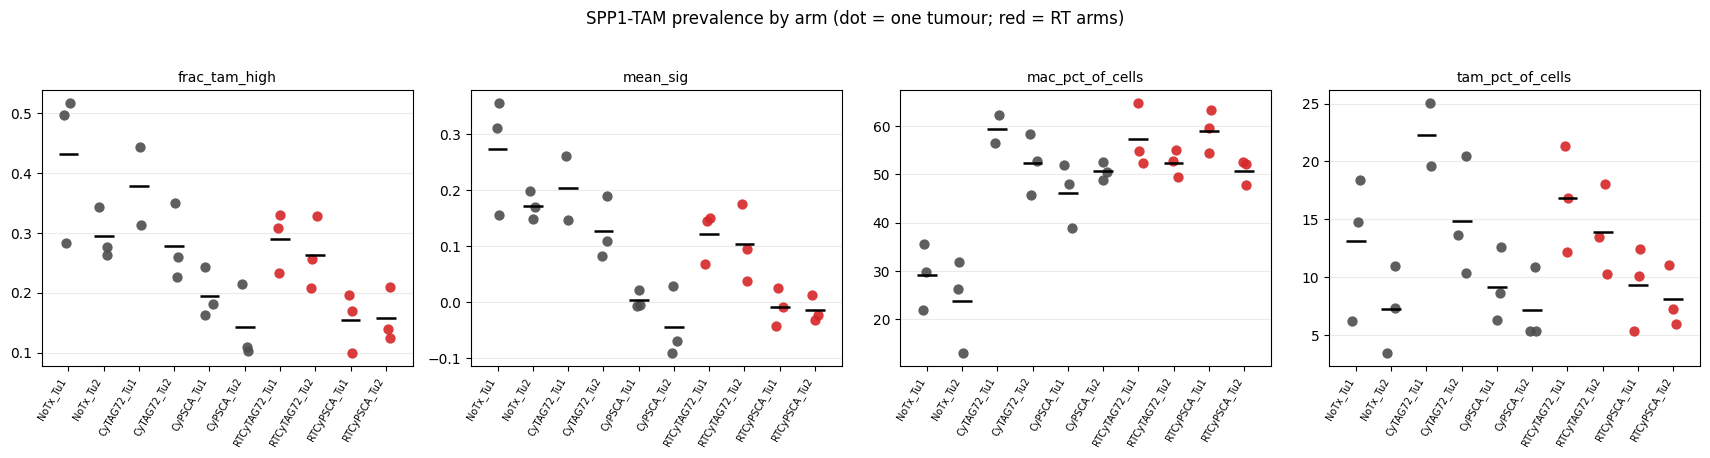

In [5]:
colors = {c: ("#d62728" if COND_META.get(c, {}).get("RT") else "#4d4d4d") for c in COND_PRESENT}
rng = np.random.default_rng(0)
xmap = {g: i for i, g in enumerate(GROUPS)}
fig, axes = plt.subplots(1, len(METRICS), figsize=(4.3 * len(METRICS), 4.4))
for ax, met in zip(np.atleast_1d(axes), METRICS):
    for g in GROUPS:
        s = prev[prev["group"] == g]
        v = s[met].dropna().values
        ax.scatter(xmap[g] + rng.uniform(-0.13, 0.13, len(v)), v, s=55,
                   color=colors.get(s["cond"].iloc[0] if len(s) else "NoTx", "k"),
                   alpha=0.9, linewidths=0, zorder=3)
        if len(v):
            ax.hlines(np.mean(v), xmap[g] - 0.28, xmap[g] + 0.28, color="k", lw=1.8, zorder=4)
    ax.set_xticks(list(xmap.values())); ax.set_xticklabels(GROUPS, rotation=60, ha="right", fontsize=7)
    ax.set_title(met, fontsize=10); ax.grid(axis="y", alpha=0.25)
fig.suptitle("SPP1-TAM prevalence by arm (dot = one tumour; red = RT arms)", y=1.03, fontsize=12)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1tam_prevalence.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 4. Recruitment vs state

`tam_pct_of_cells = mac_pct_of_cells x frac_tam_high`, so on a log2 scale the burden change
decomposes **additively** into a recruitment term and a state term:

`log2(burden) = log2(mac abundance) + log2(fraction high)`

Which term dominates decides the mechanism — and the follow-up experiment.

In [6]:
# tam_pct = mac_pct x frac_high holds EXACTLY per sample, so in log2 space the burden is exactly
# the sum of the two terms. We therefore log-transform PER SAMPLE and average the logs (a geometric
# mean). Averaging the raw ratios first would break additivity, because E[XY] != E[X]E[Y] whenever
# recruitment and state covary across replicates within an arm.
LOGCOLS = {"log2_recruitment": "mac_pct_of_cells",
           "log2_state":       "frac_tam_high",
           "log2_burden":      "tam_pct_of_cells"}
lg = prev[["sample", "cond", "tumor_loc", "group"]].copy()
for k, m in LOGCOLS.items():
    lg[k] = np.log2(prev[m].where(prev[m] > 0))

NOTX = next((c for c in COND_PRESENT if COND_META.get(c, {}).get("cart") == "none"), None)
assert NOTX is not None, "no untreated arm found to use as the baseline"
ref = lg[lg["cond"] == NOTX].groupby("tumor_loc", observed=True)[list(LOGCOLS)].mean()

rows = []
for (g, tloc), d in lg.groupby(["group", "tumor_loc"], observed=True):
    if g == f"{NOTX}_Tu{tloc}" or tloc not in ref.index:
        continue
    rec = {"group": g, "tumor_loc": tloc, "n_samples": len(d)}
    for k in LOGCOLS:
        rec[k] = float(d[k].mean() - ref.loc[tloc, k])
    rows.append(rec)
decomp = pd.DataFrame(rows)
decomp["driver"] = np.where(
    decomp[["log2_recruitment", "log2_state"]].isna().any(axis=1), "n/a",
    np.where(decomp["log2_recruitment"].abs() > decomp["log2_state"].abs(), "recruitment", "state"))
decomp["additivity_err"] = (decomp["log2_recruitment"] + decomp["log2_state"]
                            - decomp["log2_burden"]).abs()
decomp.to_csv(OUT_DIR / "sc_spp1tam_decomposition_vs_NoTx.csv", index=False)
print("=== change vs NoTx (same tumour location), log2 ===")
print(decomp.round(3).to_string(index=False))
print(f"\n  additivity check (recruitment + state - burden): max |err| = "
      f"{decomp['additivity_err'].max():.2e}  (must be ~0)")
print("""
  log2_state dominant      -> the same macrophages carry less of the SPP1-TAM program (reprogramming)
  log2_recruitment dominant-> the macrophage compartment itself changed size (trafficking)
  NOTE the recruitment term inherits single-cell capture bias; the state term does not.""")

=== change vs NoTx (same tumour location), log2 ===
        group  tumor_loc  n_samples  log2_recruitment  log2_state  log2_burden      driver  additivity_err
   CyPSCA_Tu1          1          3             0.686      -1.118       -0.433       state             0.0
   CyPSCA_Tu2          2          3             1.192      -1.127        0.065 recruitment             0.0
  CyTAG72_Tu1          1          2             1.056      -0.161        0.895 recruitment             0.0
  CyTAG72_Tu2          2          3             1.230      -0.092        1.138 recruitment             0.0
 RTCyPSCA_Tu1          1          3             1.046      -1.489       -0.443       state             0.0
 RTCyPSCA_Tu2          2          3             1.194      -0.926        0.268 recruitment             0.0
RTCyTAG72_Tu1          1          3             1.001      -0.540        0.461 recruitment             0.0
RTCyTAG72_Tu2          2          3             1.240      -0.172        1.068 recruitment  

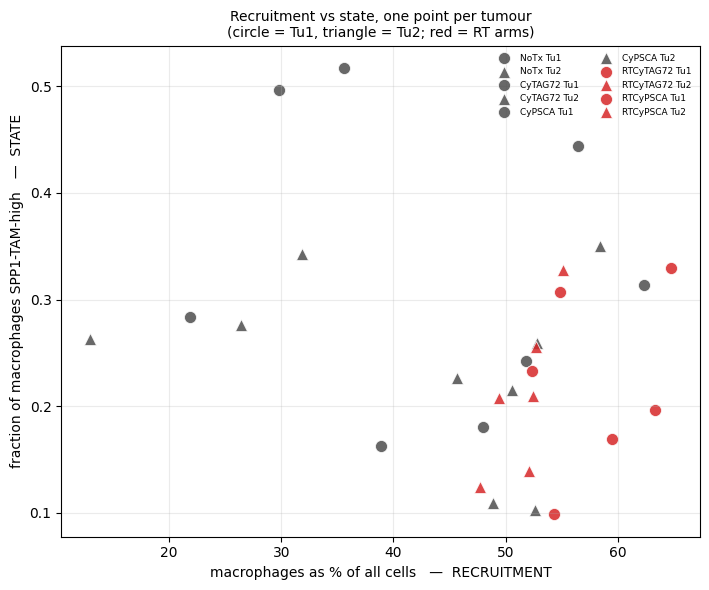

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 6))
mk = {1: "o", 2: "^"}
for cnd in COND_PRESENT:
    s = prev[prev["cond"] == cnd]
    if s.empty:
        continue
    for loc, sub in s.groupby("tumor_loc", observed=True):
        ax.scatter(sub["mac_pct_of_cells"], sub["frac_tam_high"], s=75, marker=mk.get(loc, "s"),
                   color=colors.get(cnd, "k"), alpha=0.85, linewidths=0.6, edgecolors="w",
                   label=f"{cnd} Tu{loc}")
ax.set_xlabel("macrophages as % of all cells   —  RECRUITMENT")
ax.set_ylabel("fraction of macrophages SPP1-TAM-high   —  STATE")
ax.set_title("Recruitment vs state, one point per tumour\n(circle = Tu1, triangle = Tu2; red = RT arms)",
             fontsize=10)
ax.legend(fontsize=6.5, ncol=2, frameon=False); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1tam_recruitment_vs_state.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 5. Which macrophage subtype are the SPP1-TAMs, per arm?

01c §4b found an M2 skew; 05 found M1-like macrophages expand 2-3 log2 with treatment. So the
subtype identity of the SPP1-TAM pool may itself shift with therapy. Composition is computed
**within** the SPP1-TAM-high pool, and compared against each arm's overall macrophage make-up.

In [8]:
rows = []
for (cnd, sub_ct), d in obs[obs["is_mac"]].groupby(["cond", "mac_subtype"], observed=True):
    tot_mac = int((obs["is_mac"] & obs["cond"].eq(cnd)).sum())
    tot_high = int((obs["tam_high"] & obs["cond"].eq(cnd)).sum())
    rows.append({"cond": cnd, "subtype": sub_ct,
                 "pct_of_macs": 100 * len(d) / tot_mac if tot_mac else np.nan,
                 "pct_of_tam_high": 100 * int(d["tam_high"].sum()) / tot_high if tot_high else np.nan,
                 "frac_high_within_subtype": float(d["tam_high"].mean())})
subtype = pd.DataFrame(rows)
subtype["log2_enrich_in_tam"] = np.log2(subtype["pct_of_tam_high"] / subtype["pct_of_macs"]).replace(
    [np.inf, -np.inf], np.nan)
subtype.to_csv(OUT_DIR / "sc_spp1tam_subtype_composition.csv", index=False)

piv = subtype.pivot_table(index="subtype", columns="cond", values="pct_of_tam_high", observed=True)
piv = piv.reindex(columns=[c for c in COND_PRESENT if c in piv.columns])
print("=== composition of the SPP1-TAM-high pool (% from each subtype), per arm ===")
print(piv.round(1).to_string())
piv2 = subtype.pivot_table(index="subtype", columns="cond", values="frac_high_within_subtype", observed=True)
piv2 = piv2.reindex(columns=[c for c in COND_PRESENT if c in piv2.columns])
print("\n=== fraction of each subtype that is SPP1-TAM-high, per arm ===")
print(piv2.round(3).to_string())
print("\n  row differences here = which macrophage subtype actually carries the program in each arm.")

=== composition of the SPP1-TAM-high pool (% from each subtype), per arm ===
cond               NoTx  CyTAG72  CyPSCA  RTCyTAG72  RTCyPSCA
subtype                                                      
Intermediate_Mac    0.0      0.0     0.0        0.0       0.1
M1_like_Mac         0.0      0.2     0.0        0.1       0.0
M2_like_Mac       100.0     99.8   100.0       99.8      99.9

=== fraction of each subtype that is SPP1-TAM-high, per arm ===
cond               NoTx  CyTAG72  CyPSCA  RTCyTAG72  RTCyPSCA
subtype                                                      
Intermediate_Mac  0.000    0.000   0.000      0.001     0.000
M1_like_Mac       0.000    0.003   0.000      0.001     0.000
M2_like_Mac       0.494    0.558   0.499      0.524     0.444

  row differences here = which macrophage subtype actually carries the program in each arm.


## 5b. The M2 decomposition — *why* SPP1-TAM prevalence falls

§5 shows two things at once: the SPP1-TAM pool is **~100% M2-like** in every arm, and the fraction
of M2 macrophages carrying the program is nearly **constant** (0.44-0.56). Those can only be
reconciled if the falling prevalence is driven by the **M2 share of the macrophage compartment**,
not by M2 cells switching the program off.

Because M1 and Intermediate macrophages carry the program at ~0%, prevalence factorises cleanly:

`frac_tam_high  =  M2 share of macrophages  x  fraction of M2s that are SPP1-TAM-high`

so on a log2 scale the change versus untreated splits additively into a **compartment** term and a
**state** term. Both are proportions computed *within* the macrophage compartment, so unlike
`mac_pct_of_cells` neither is distorted by dissociation capture bias or by tumour depletion — this
is the trustworthy version of the recruitment-vs-state decomposition in §4.

If the compartment term dominates, therapy is acting by **repolarising or depleting M2
macrophages**, not by reprogramming the SPP1-TAM state inside them — a different mechanism, and a
different therapeutic implication.

=== M2 decomposition of SPP1-TAM prevalence ===
           n  frac_tam_high  m2_share  m2_rate
cond                                          
NoTx       6          0.363     0.766    0.469
CyTAG72    5          0.319     0.579    0.545
CyPSCA     6          0.169     0.353    0.469
RTCyTAG72  6          0.277     0.542    0.512
RTCyPSCA   6          0.156     0.360    0.432

  factorisation frac_tam_high ~ m2_share x m2_rate: max |err| = 0.0011   (small = M1/Intermediate carry ~none of the program)

=== log2 change vs NoTx: compartment term vs state term ===
           n  log2_M2_compartment  log2_within_M2_state  log2_prevalence  pct_movement_from_compartment
cond                                                                                                   
CyTAG72    5               -0.394                 0.272           -0.119                         59.195
CyPSCA     6               -1.144                 0.022           -1.122                         98.118
RTCyTAG72  6       

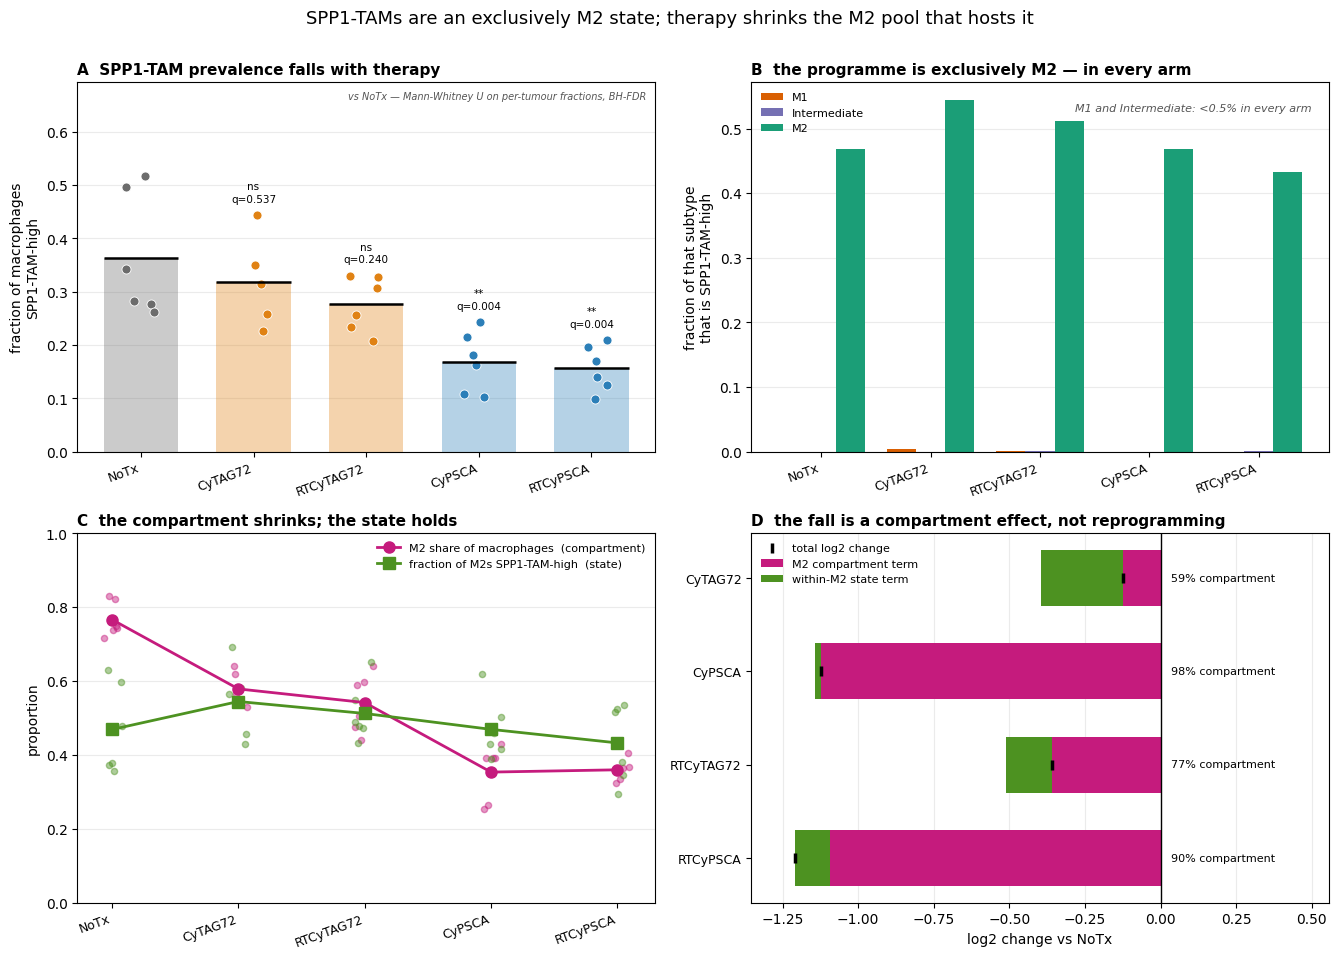


saved -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis/figures/sc_spp1tam_m2_decomposition.png


In [9]:
# %% -- 5b. M2 decomposition of SPP1-TAM prevalence + summary figure --
M2, M1, INT = "M2_like_Mac", "M1_like_Mac", "Intermediate_Mac"
SUBTYPES = [s for s in [M1, INT, M2] if s in set(obs.loc[obs["is_mac"], "mac_subtype"])]

rows = []
for samp, d in obs.groupby("sample", observed=True):
    macs = d[d["is_mac"]]
    if len(macs) < MIN_MACS:
        continue
    m = d.iloc[0]
    rec = {"sample": samp, "cond": m["cond"], "tumor_loc": m["tumor_loc"], "group": m["group"],
           "n_mac": len(macs), "frac_tam_high": float(macs["tam_high"].mean())}
    for s in SUBTYPES:
        sub = macs[macs["mac_subtype"] == s]
        rec[f"share_{s}"] = len(sub) / len(macs)
        rec[f"rate_{s}"] = float(sub["tam_high"].mean()) if len(sub) else np.nan
    # the factorisation, and how much of prevalence the M2 term alone explains
    rec["m2_share"], rec["m2_rate"] = rec[f"share_{M2}"], rec[f"rate_{M2}"]
    rec["approx_from_M2"] = rec["m2_share"] * (rec["m2_rate"] if np.isfinite(rec["m2_rate"]) else 0.0)
    rows.append(rec)
m2d = pd.DataFrame(rows)
m2d["cond"] = pd.Categorical(m2d["cond"], COND_PRESENT, ordered=True)
m2d["factorisation_err"] = (m2d["approx_from_M2"] - m2d["frac_tam_high"]).abs()
m2d.to_csv(OUT_DIR / "sc_spp1tam_m2_decomposition_per_sample.csv", index=False)

by_arm = (m2d.groupby("cond", observed=True)
          .agg(n=("sample", "count"), frac_tam_high=("frac_tam_high", "mean"),
               m2_share=("m2_share", "mean"), m2_rate=("m2_rate", "mean"),
               **{f"rate_{s}": (f"rate_{s}", "mean") for s in SUBTYPES},
               **{f"share_{s}": (f"share_{s}", "mean") for s in SUBTYPES})
          .reindex(COND_PRESENT))
by_arm.to_csv(OUT_DIR / "sc_spp1tam_m2_decomposition_by_arm.csv")

print("=== M2 decomposition of SPP1-TAM prevalence ===")
print(by_arm[["n", "frac_tam_high", "m2_share", "m2_rate"]].round(3).to_string())
print(f"\n  factorisation frac_tam_high ~ m2_share x m2_rate: max |err| = "
      f"{m2d['factorisation_err'].max():.4f}   (small = M1/Intermediate carry ~none of the program)")

# log2 split vs the untreated arm: compartment term + state term
lgm = m2d[["sample", "cond", "tumor_loc"]].copy()
for k, col in {"log2_M2_compartment": "m2_share", "log2_within_M2_state": "m2_rate",
               "log2_prevalence": "frac_tam_high"}.items():
    lgm[k] = np.log2(m2d[col].where(m2d[col] > 0))
refm = lgm[lgm["cond"] == NOTX].groupby("tumor_loc", observed=True)[
    ["log2_M2_compartment", "log2_within_M2_state", "log2_prevalence"]].mean()

rows = []
for cnd, d in lgm.groupby("cond", observed=True):
    if cnd == NOTX:
        continue
    rec = {"cond": cnd, "n": len(d)}
    for k in ["log2_M2_compartment", "log2_within_M2_state", "log2_prevalence"]:
        rec[k] = float(np.mean([d[k].values[i] - refm.loc[d["tumor_loc"].values[i], k]
                                for i in range(len(d)) if np.isfinite(d[k].values[i])]))
    # share of TOTAL MOVEMENT, not of the sum: the two terms can have opposite signs (a shrinking
    # compartment with a slightly rising within-M2 rate), which makes a share-of-sum exceed 100%.
    denom = abs(rec["log2_M2_compartment"]) + abs(rec["log2_within_M2_state"])
    rec["pct_movement_from_compartment"] = (100 * abs(rec["log2_M2_compartment"]) / denom
                                            if denom else np.nan)
    rows.append(rec)
m2_split = pd.DataFrame(rows).set_index("cond").reindex([c for c in COND_PRESENT if c != NOTX])
m2_split.to_csv(OUT_DIR / "sc_spp1tam_m2_split_vs_NoTx.csv")
print(f"\n=== log2 change vs {NOTX}: compartment term vs state term ===")
print(m2_split.round(3).to_string())
print("\n  pct_movement_from_compartment >> 50 -> therapy shrinks the M2 pool that hosts the")
print("  programme, rather than switching the programme off inside M2 cells.")

# ---------------- figure ----------------
ORDER = [c for c in ["NoTx", "CyTAG72", "RTCyTAG72", "CyPSCA", "RTCyPSCA"] if c in COND_PRESENT]
CART_C = {"none": "#6c6c6c", "nonspecific": "#e08214", "PSCA": "#2c7fb8"}
ccol = {c: CART_C.get(COND_META.get(c, {}).get("cart", "none"), "#6c6c6c") for c in ORDER}
rng2 = np.random.default_rng(0)
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5))

# A — prevalence per arm, replicate dots + significance vs NoTx
ax = axes[0, 0]
for i, c in enumerate(ORDER):
    v = m2d.loc[m2d["cond"] == c, "frac_tam_high"].dropna().values
    ax.bar(i, v.mean(), color=ccol[c], alpha=0.35, width=0.66, zorder=1)
    ax.scatter(i + rng2.uniform(-0.14, 0.14, len(v)), v, s=42, color=ccol[c],
               edgecolors="w", linewidths=0.6, zorder=3)
    ax.hlines(v.mean(), i - 0.33, i + 0.33, color="k", lw=1.8, zorder=4)

# Mann-Whitney U vs NoTx on per-tumour fractions, BH-FDR over these 4 comparisons.
# Identical test/family to section 5c, so the q-values there match these exactly.
_arms = [c for c in ORDER if c != NOTX]
_ref  = m2d.loc[m2d["cond"] == NOTX, "frac_tam_high"].dropna().values
_pv   = np.array([mannwhitneyu(m2d.loc[m2d["cond"] == c, "frac_tam_high"].dropna().values,
                               _ref, alternative="two-sided")[1] for c in _arms])
_o = np.argsort(_pv); _q = np.empty(len(_pv))
_q[_o] = np.minimum.accumulate((_pv[_o] * len(_pv) / np.arange(1, len(_pv) + 1))[::-1])[::-1]
_q = np.clip(_q, 0, 1)
_ytop = float(m2d["frac_tam_high"].max())
for c, q in zip(_arms, _q):
    v = m2d.loc[m2d["cond"] == c, "frac_tam_high"].dropna().values
    lab = "***" if q < .001 else "**" if q < .01 else "*" if q < .05 else "ns"
    ax.text(ORDER.index(c), v.max() + 0.04 * _ytop, f"{lab}\nq={q:.3f}", ha="center",
            va="bottom", fontsize=7.5, linespacing=1.35)
ax.set_ylim(0, _ytop * 1.34)
ax.text(0.985, 0.975, "vs NoTx — Mann-Whitney U on per-tumour fractions, BH-FDR",
        transform=ax.transAxes, ha="right", va="top", fontsize=7, style="italic", color="#555")

ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("fraction of macrophages\nSPP1-TAM-high")
ax.set_title("A  SPP1-TAM prevalence falls with therapy", fontsize=11, loc="left", fontweight="bold")
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)

# B — lineage restriction: rate within each subtype
ax = axes[0, 1]
w = 0.8 / len(SUBTYPES)
sub_c = {M1: "#d95f02", INT: "#7570b3", M2: "#1b9e77"}
for j, s in enumerate(SUBTYPES):
    vals = [by_arm.loc[c, f"rate_{s}"] for c in ORDER]
    ax.bar(np.arange(len(ORDER)) + j * w - 0.4 + w / 2, vals, width=w,
           color=sub_c.get(s, "#999"), label=s.replace("_like_Mac", "").replace("_Mac", ""))
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("fraction of that subtype\nthat is SPP1-TAM-high")
ax.set_title("B  the programme is exclusively M2 — in every arm", fontsize=11, loc="left", fontweight="bold")
ax.text(0.97, 0.93, "M1 and Intermediate: <0.5% in every arm", transform=ax.transAxes,
        ha="right", va="center", fontsize=8, style="italic", color="#555")
ax.legend(fontsize=8, frameon=False, loc="upper left")
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)

# C — the two factors: compartment moves, state does not
ax = axes[1, 0]
x = np.arange(len(ORDER))
ax.plot(x, [by_arm.loc[c, "m2_share"] for c in ORDER], "-o", color="#c51b7d", lw=2, ms=8,
        label="M2 share of macrophages  (compartment)")
ax.plot(x, [by_arm.loc[c, "m2_rate"] for c in ORDER], "-s", color="#4d9221", lw=2, ms=8,
        label="fraction of M2s SPP1-TAM-high  (state)")
for i, c in enumerate(ORDER):
    v = m2d.loc[m2d["cond"] == c]
    ax.scatter(np.repeat(i, len(v)) + rng2.uniform(-.09, .09, len(v)), v["m2_share"],
               s=20, color="#c51b7d", alpha=.45, zorder=1)
    ax.scatter(np.repeat(i, len(v)) + rng2.uniform(-.09, .09, len(v)), v["m2_rate"],
               s=20, color="#4d9221", alpha=.45, zorder=1)
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("proportion"); ax.set_ylim(0, 1)
ax.set_title("C  the compartment shrinks; the state holds", fontsize=11, loc="left", fontweight="bold")
ax.legend(fontsize=8, frameon=False, loc="upper right"); ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)

# D — how the log2 drop splits
ax = axes[1, 1]
arms = list(m2_split.index); y = np.arange(len(arms))
comp = m2_split["log2_M2_compartment"].values
stat = m2_split["log2_within_M2_state"].values
ax.barh(y, comp, color="#c51b7d", label="M2 compartment term", height=0.6)
ax.barh(y, stat, left=comp, color="#4d9221", label="within-M2 state term", height=0.6)
ax.scatter(comp + stat, y, color="k", zorder=5, s=60, marker="|", linewidths=2.5,
           label="total log2 change")
span = float(np.nanmax(np.abs(np.r_[comp, comp + stat]))) or 1.0
ax.set_xlim(-1.12 * span, 0.46 * span)          # right margin holds the annotations
for i, a in enumerate(arms):
    sh = m2_split.loc[a, "pct_movement_from_compartment"]
    if np.isfinite(sh):
        ax.text(0.03 * span, i, f"{sh:.0f}% compartment", va="center", ha="left", fontsize=8)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(y); ax.set_yticklabels(arms, fontsize=9); ax.invert_yaxis()
ax.set_xlabel(f"log2 change vs {NOTX}")
ax.set_title("D  the fall is a compartment effect, not reprogramming", fontsize=11,
             loc="left", fontweight="bold")
ax.legend(fontsize=8, frameon=False, loc="upper left"); ax.grid(axis="x", alpha=0.25); ax.set_axisbelow(True)

fig.suptitle("SPP1-TAMs are an exclusively M2 state; therapy shrinks the M2 pool that hosts it",
             fontsize=13, y=1.005)
fig.tight_layout()
fig.savefig(FIG_DIR / "sc_spp1tam_m2_decomposition.png", dpi=200, bbox_inches="tight")
plt.show(); plt.close(fig)
print("\nsaved ->", FIG_DIR / "sc_spp1tam_m2_decomposition.png")

## 5c. Is the prevalence difference between arms significant?

Panel A shows the fall; this section tests it. The hard part is not the test, it is the **unit of
analysis**.

- There are **48,475 macrophages**, but testing at the cell level would be pseudoreplication of the
  worst kind — it treats cells from one mouse as independent replicates and returns p ~ 1e-300 for
  any difference at all. It is not run here.
- The honest experimental unit is the **mouse**, and there are only **3 per arm** — each mouse
  contributes two tumours (Tu1 and Tu2), so the 6 samples per arm are *paired*, not independent.
- Tumour location is a real nuisance factor (NoTx: 0.432 at Tu1 vs 0.294 at Tu2), so it should not
  be ignored.

Three tests are therefore reported, from most conventional to most conservative:

| test | unit | n / arm | what it buys |
|---|---|---|---|
| **1** Kruskal-Wallis + pairwise Mann-Whitney, BH-FDR | tumour | 5-6 | the convention for this figure; **this is what panel A annotates** |
| **2** exact permutation on mouse means | mouse | 3 | removes the pseudoreplication, but *floors at p = 0.1* — 3 vs 3 can never reach p < 0.05 |
| **3** global permutation across all mice | mouse | 3 x 5 | the only mouse-level test with enough resolution to reject |

Read them together. Test 1 is the reportable number; test 3 confirms an overall arm effect exists at
the mouse level; test 2 exists to show honestly that no *individual pair* can clear 0.05 once you
respect the mouse as the unit. If test 1 and test 3 agree, the effect is real and the limitation is
resolution, not direction.


In [10]:
# %% -- 5c. Significance testing for panel A --
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu, rankdata

def bh_fdr(p):
    """Benjamini-Hochberg q-values."""
    p = np.asarray(p, float); n = len(p); o = np.argsort(p)
    q = np.empty(n, float)
    q[o] = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.clip(q, 0, 1)

def stars(q):
    return "***" if q < 0.001 else "**" if q < 0.01 else "*" if q < 0.05 else "ns"

STAT_ORDER = [c for c in ["NoTx", "CyTAG72", "RTCyTAG72", "CyPSCA", "RTCyPSCA"] if c in COND_PRESENT]
samp_lvl = prev[["sample", "mouse", "cond", "tumor_loc", "n_mac", "frac_tam_high"]].copy()
samp_lvl["cond"] = samp_lvl["cond"].astype(str)

print("=== unit of analysis ===")
print(samp_lvl.groupby("cond", observed=True)
      .agg(n_tumours=("sample", "count"), n_mice=("mouse", "nunique"), n_mac=("n_mac", "sum"))
      .reindex(STAT_ORDER).to_string())
print("\n  each mouse carries TWO tumours -> the 6 samples/arm are paired, not independent.")
print(f"  cell-level testing over {int(samp_lvl['n_mac'].sum()):,} macrophages would be pseudoreplication; not run.")

# ---------------- TEST 1: tumour level (what panel A annotates) ----------------
grp = [samp_lvl.loc[samp_lvl["cond"] == c, "frac_tam_high"].values for c in STAT_ORDER]
H, p_kw = kruskal(*grp)
print(f"\n=== TEST 1a  global Kruskal-Wallis, tumour level  (n = {[len(g) for g in grp]}) ===")
print(f"  H = {H:.3f},  p = {p_kw:.3g}   {'-> arms differ' if p_kw < .05 else '-> no overall arm effect'}")

ref = samp_lvl.loc[samp_lvl["cond"] == NOTX, "frac_tam_high"].values
rows = []
for c in [x for x in STAT_ORDER if x != NOTX]:
    v = samp_lvl.loc[samp_lvl["cond"] == c, "frac_tam_high"].values
    U, p = mannwhitneyu(v, ref, alternative="two-sided")
    rows.append({"arm": c, "n": len(v), "mean": v.mean(), "mean_NoTx": ref.mean(),
                 "diff": v.mean() - ref.mean(), "pct_change": 100 * (v.mean() / ref.mean() - 1),
                 "cliffs_delta": 2 * U / (len(v) * len(ref)) - 1, "p": p})
vs_notx = pd.DataFrame(rows)
vs_notx["q_BH"] = bh_fdr(vs_notx["p"]); vs_notx["sig"] = [stars(q) for q in vs_notx["q_BH"]]
vs_notx.to_csv(OUT_DIR / "sc_spp1tam_prevalence_stats_vs_NoTx.csv", index=False)
print(f"\n=== TEST 1b  each arm vs {NOTX}  (Mann-Whitney U, BH-FDR over {len(vs_notx)}) ===")
print(vs_notx.round(4).to_string(index=False))
print("  cliffs_delta: -1 = every tumour in this arm below every NoTx tumour; 0 = no separation.")

rows = []
for a, b in combinations(STAT_ORDER, 2):
    va = samp_lvl.loc[samp_lvl["cond"] == a, "frac_tam_high"].values
    vb = samp_lvl.loc[samp_lvl["cond"] == b, "frac_tam_high"].values
    U, p = mannwhitneyu(va, vb, alternative="two-sided")
    rows.append({"arm_A": a, "arm_B": b, "n_A": len(va), "n_B": len(vb),
                 "mean_A": va.mean(), "mean_B": vb.mean(), "diff": va.mean() - vb.mean(),
                 "cliffs_delta": 2 * U / (len(va) * len(vb)) - 1, "p": p})
pairs = pd.DataFrame(rows)
pairs["q_BH"] = bh_fdr(pairs["p"]); pairs["sig"] = [stars(q) for q in pairs["q_BH"]]
pairs.to_csv(OUT_DIR / "sc_spp1tam_prevalence_stats_all_pairs.csv", index=False)
print(f"\n=== TEST 1c  all {len(pairs)} pairwise comparisons (exploratory, BH-FDR over {len(pairs)}) ===")
print(pairs.round(4).to_string(index=False))

# ---------------- TEST 2: mouse level, exact permutation ----------------
mouse = samp_lvl.groupby(["cond", "mouse"], observed=True)["frac_tam_high"].mean().reset_index()
rows = []
for a, b in combinations(STAT_ORDER, 2):
    va = mouse.loc[mouse["cond"] == a, "frac_tam_high"].values
    vb = mouse.loc[mouse["cond"] == b, "frac_tam_high"].values
    pooled = np.concatenate([va, vb]); na, n_all = len(va), len(va) + len(vb)
    # NB: do NOT name this `obs` -- that is the global cell-level DataFrame.
    stat_obs = abs(va.mean() - vb.mean())
    null = []
    for comb in combinations(range(n_all), na):
        m = np.zeros(n_all, bool); m[list(comb)] = True
        null.append(abs(pooled[m].mean() - pooled[~m].mean()))
    null = np.asarray(null)
    rows.append({"arm_A": a, "arm_B": b, "n_mice_A": na, "n_mice_B": len(vb),
                 "diff": va.mean() - vb.mean(),
                 "p_exact": float((null >= stat_obs - 1e-12).mean()),
                 "min_possible_p": 2.0 / len(null)})
mouse_pairs = pd.DataFrame(rows)
mouse_pairs["sig"] = [stars(p) for p in mouse_pairs["p_exact"]]
mouse_pairs.to_csv(OUT_DIR / "sc_spp1tam_prevalence_stats_mouse_level.csv", index=False)
print("\n=== TEST 2  mouse level, exact permutation on mouse means ===")
print(mouse_pairs.round(4).to_string(index=False))
print("  NOTE min_possible_p is the FLOOR set by the number of mice: with 3 vs 3 no pair can")
print("  ever reach p < 0.05, even with perfect separation. A non-significant p here is a")
print("  statement about n, not about the biology.")

# ---------------- TEST 3: global permutation across all mice ----------------
mg = [mouse.loc[mouse["cond"] == c, "frac_tam_high"].values for c in STAT_ORDER]
allv = np.concatenate(mg)
lab0 = np.concatenate([np.full(len(g), j) for j, g in enumerate(mg)])
R = rankdata(allv); N = len(R); K = len(mg)

def _H(lab):   # Kruskal-Wallis H from fixed ranks; tie correction is constant so permutation-equivalent
    return 12.0 / (N * (N + 1)) * sum(R[lab == j].sum() ** 2 / max((lab == j).sum(), 1)
                                      for j in range(K)) - 3 * (N + 1)

N_PERM = 20000
rng_s = np.random.default_rng(0)
H_obs = _H(lab0)
null = np.array([_H(rng_s.permutation(lab0)) for _ in range(N_PERM)])
p_perm = (1 + int((null >= H_obs - 1e-12).sum())) / (1 + N_PERM)
print(f"\n=== TEST 3  global permutation across all {N} mice ({N_PERM:,} relabelings) ===")
print(f"  H = {H_obs:.3f},  p = {p_perm:.4f},  resolution floor = {1/(1+N_PERM):.5f}")
print(f"  {'-> arms differ at the MOUSE level' if p_perm < .05 else '-> no arm effect at the mouse level'}")

print(f"""
==================== HOW TO REPORT PANEL A ====================
Quote TEST 1: 'Mann-Whitney U on per-tumour macrophage fractions (n = 5-6 tumours from 3 mice
per arm), Benjamini-Hochberg FDR across the {len(vs_notx)} comparisons to {NOTX}.'  Those are the
q-values annotated on panel A.

State the caveat rather than hiding it: tumours within a mouse are not independent, and at the
mouse level (n = 3/arm) no pairwise contrast can reach p < 0.05 by construction. TEST 3 is the
mouse-level evidence that an arm effect exists; TEST 1 localises which arms drive it.

The effect size carries the argument here more than the p-value -- report diff / pct_change and
Cliff's delta alongside q, and note that the direction is consistent in every tumour if
cliffs_delta is at or near -1.
===============================================================""")


=== unit of analysis ===
           n_tumours  n_mice  n_mac
cond                               
NoTx               6       3   2059
CyTAG72            5       3  12216
RTCyTAG72          6       3  14413
CyPSCA             6       3   7558
RTCyPSCA           6       3  12229

  each mouse carries TWO tumours -> the 6 samples/arm are paired, not independent.
  cell-level testing over 48,475 macrophages would be pseudoreplication; not run.

=== TEST 1a  global Kruskal-Wallis, tumour level  (n = [6, 5, 6, 6, 6]) ===
  H = 19.655,  p = 0.000584   -> arms differ

=== TEST 1b  each arm vs NoTx  (Mann-Whitney U, BH-FDR over 4) ===
      arm  n   mean  mean_NoTx    diff  pct_change  cliffs_delta      p   q_BH sig
  CyTAG72  5 0.3189     0.3632 -0.0443    -12.2042       -0.2667 0.5368 0.5368  ns
RTCyTAG72  6 0.2770     0.3632 -0.0862    -23.7238       -0.5000 0.1797 0.2395  ns
   CyPSCA  6 0.1686     0.3632 -0.1946    -53.5827       -1.0000 0.0022 0.0043  **
 RTCyPSCA  6 0.1563     0.3632 -0.2

## 5d. Main figure — prevalence + compartment-vs-state, side by side

Panels A and C of the §5b figure, rebuilt as a standalone two-panel figure for the manuscript.
The compartment-vs-state panel is relabelled **C -> B** here, since this figure only has two panels.

Two changes from §5b:

- **`NoTx` -> `Control`** on the axis labels of both panels. This is display-only — the underlying
  arm names are untouched everywhere else. The CAR-T arms keep their full `CyTAG72` / `RTCyTAG72`
  names so the non-specific-CAR-T component stays visible in the figure.
- **Panel A now brackets the PSCA-vs-non-specific contrasts** (CyPSCA and RTCyPSCA against CyTAG72
  and RTCyTAG72) rather than the contrasts to the control arm. That is the comparison that shows the effect is specific
  to PSCA targeting rather than a generic consequence of Cy + CAR-T.

The q-values are recomputed here from the **same all-pairs BH family as §5c TEST 1c**, so the stars
on this figure are numerically identical to `sc_spp1tam_prevalence_stats_all_pairs.csv`. Correcting
over only the 4 plotted contrasts would give smaller q-values for the same data, which would not be
honest — all 10 contrasts were examined.


=== contrasts drawn on panel A (BH-FDR over all 10 pairwise tests) ===
             contrast     arm_A    arm_B  mean_A  mean_B   q_BH sig
  RTCyTAG72 vs CyPSCA RTCyTAG72   CyPSCA  0.2770  0.1686 0.0253   *
    CyTAG72 vs CyPSCA   CyTAG72   CyPSCA  0.3189  0.1686 0.0173   *
RTCyTAG72 vs RTCyPSCA RTCyTAG72 RTCyPSCA  0.2770  0.1563 0.0108   *
  CyTAG72 vs RTCyPSCA   CyTAG72 RTCyPSCA  0.3189  0.1563 0.0108   *


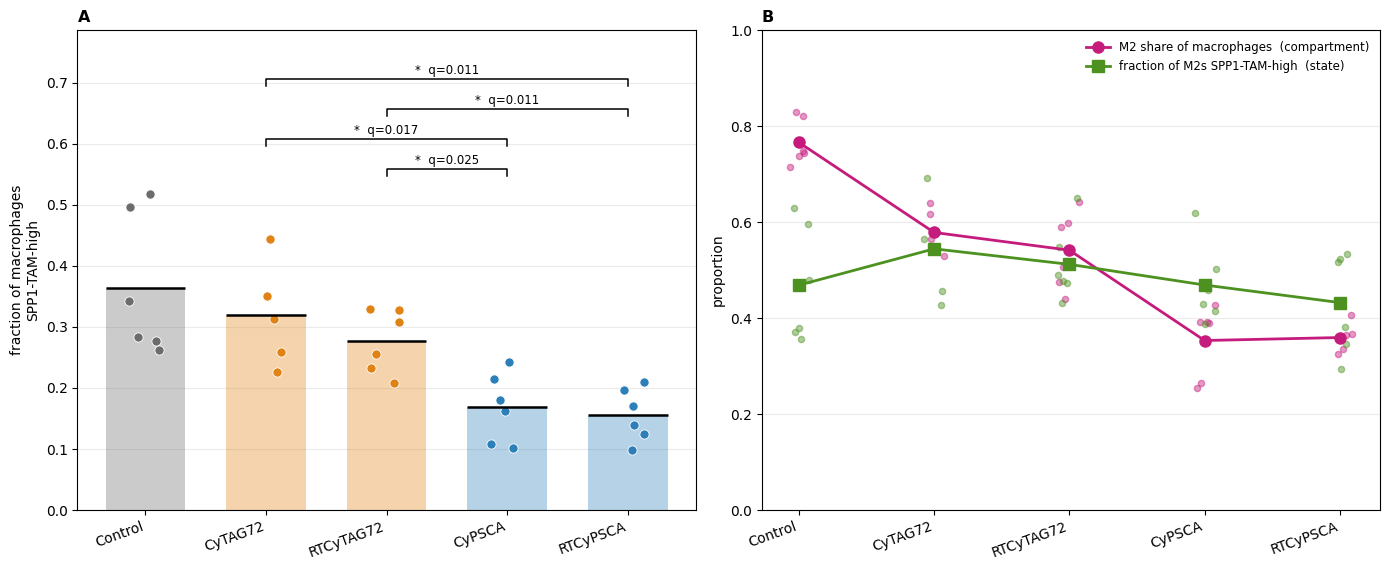


saved -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis/figures/sc_spp1tam_prevalence_and_compartment.png


In [11]:
# %% -- 5d. Main figure: prevalence (A) + compartment-vs-state (B), side by side --
from itertools import combinations
from scipy.stats import mannwhitneyu

DISPLAY = {"NoTx": "Control"}                             # display-only relabel
FIG_ORDER = [c for c in ["NoTx", "CyTAG72", "RTCyTAG72", "CyPSCA", "RTCyPSCA"] if c in COND_PRESENT]
lab_of = lambda c: DISPLAY.get(c, c)

# --- q-values: rebuild the SAME all-pairs BH family as 5c TEST 1c, so the stars drawn here are
#     numerically identical to sc_spp1tam_prevalence_stats_all_pairs.csv --------------------------
_fam = []
for a, b in combinations(FIG_ORDER, 2):
    va = m2d.loc[m2d["cond"] == a, "frac_tam_high"].dropna().values
    vb = m2d.loc[m2d["cond"] == b, "frac_tam_high"].dropna().values
    _fam.append({"a": a, "b": b, "p": mannwhitneyu(va, vb, alternative="two-sided")[1]})
_fam = pd.DataFrame(_fam)
_p = _fam["p"].to_numpy(float); _n = len(_p); _o = np.argsort(_p)
_qq = np.empty(_n); _qq[_o] = np.minimum.accumulate((_p[_o] * _n / np.arange(1, _n + 1))[::-1])[::-1]
_fam["q_BH"] = np.clip(_qq, 0, 1)
QMAP = {(r.a, r.b): r.q_BH for r in _fam.itertuples()}
QMAP.update({(b, a): q for (a, b), q in list(QMAP.items())})
star = lambda q: "***" if q < .001 else "**" if q < .01 else "*" if q < .05 else "ns"

# the focal contrasts: PSCA-targeted vs non-specific CAR-T
FOCAL = [(a, b) for a, b in [("CyTAG72", "CyPSCA"), ("RTCyTAG72", "CyPSCA"),
                             ("CyTAG72", "RTCyPSCA"), ("RTCyTAG72", "RTCyPSCA")]
         if a in FIG_ORDER and b in FIG_ORDER]
FOCAL.sort(key=lambda ab: (abs(FIG_ORDER.index(ab[1]) - FIG_ORDER.index(ab[0])),
                           FIG_ORDER.index(ab[0])))          # short spans low, so brackets nest

focal_tbl = pd.DataFrame([{
    "contrast": f"{lab_of(a)} vs {lab_of(b)}", "arm_A": a, "arm_B": b,
    "mean_A": m2d.loc[m2d["cond"] == a, "frac_tam_high"].mean(),
    "mean_B": m2d.loc[m2d["cond"] == b, "frac_tam_high"].mean(),
    "q_BH": QMAP[(a, b)], "sig": star(QMAP[(a, b)])} for a, b in FOCAL])
focal_tbl.to_csv(OUT_DIR / "sc_spp1tam_focal_contrasts_PSCA_vs_nonspecific.csv", index=False)
print("=== contrasts drawn on panel A (BH-FDR over all 10 pairwise tests) ===")
print(focal_tbl.round(4).to_string(index=False))

# ---------------------------------- figure ----------------------------------
CART_C = {"none": "#6c6c6c", "nonspecific": "#e08214", "PSCA": "#2c7fb8"}
ccol = {c: CART_C.get(COND_META.get(c, {}).get("cart", "none"), "#6c6c6c") for c in FIG_ORDER}
rng3 = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

# ---- A: prevalence per arm, with PSCA-vs-non-specific brackets ----
ax = axes[0]
for i, c in enumerate(FIG_ORDER):
    v = m2d.loc[m2d["cond"] == c, "frac_tam_high"].dropna().values
    ax.bar(i, v.mean(), color=ccol[c], alpha=0.35, width=0.66, zorder=1)
    ax.scatter(i + rng3.uniform(-0.14, 0.14, len(v)), v, s=44, color=ccol[c],
               edgecolors="w", linewidths=0.6, zorder=3)
    ax.hlines(v.mean(), i - 0.33, i + 0.33, color="k", lw=1.8, zorder=4)

dmax = float(m2d["frac_tam_high"].max())
y0, step = dmax * 1.08, dmax * 0.095
for k, (a, b) in enumerate(FOCAL):
    ia, ib = FIG_ORDER.index(a), FIG_ORDER.index(b)
    y, q = y0 + k * step, QMAP[(a, b)]
    ax.plot([ia, ia, ib, ib], [y - 0.020 * dmax, y, y, y - 0.020 * dmax],
            lw=1.1, color="k", clip_on=False, zorder=6)
    ax.text((ia + ib) / 2, y + 0.006 * dmax, f"{star(q)}  q={q:.3f}",
            ha="center", va="bottom", fontsize=8.5, zorder=6)
ax.set_ylim(0, y0 + len(FOCAL) * step + 0.06 * dmax)

ax.set_xticks(range(len(FIG_ORDER)))
ax.set_xticklabels([lab_of(c) for c in FIG_ORDER], rotation=20, ha="right", fontsize=10)
ax.set_ylabel("fraction of macrophages\nSPP1-TAM-high", fontsize=10)
ax.set_title("A",#  SPP1-TAM prevalence falls with PSCA-targeted therapy",
             fontsize=11.5, loc="left", fontweight="bold")
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)

# ---- B: the two factors ----
ax = axes[1]
x = np.arange(len(FIG_ORDER))
ax.plot(x, [by_arm.loc[c, "m2_share"] for c in FIG_ORDER], "-o", color="#c51b7d", lw=2, ms=8,
        label="M2 share of macrophages  (compartment)", zorder=3)
ax.plot(x, [by_arm.loc[c, "m2_rate"] for c in FIG_ORDER], "-s", color="#4d9221", lw=2, ms=8,
        label="fraction of M2s SPP1-TAM-high  (state)", zorder=3)
for i, c in enumerate(FIG_ORDER):
    v = m2d.loc[m2d["cond"] == c]
    ax.scatter(np.repeat(i, len(v)) + rng3.uniform(-.09, .09, len(v)), v["m2_share"],
               s=20, color="#c51b7d", alpha=.45, zorder=1)
    ax.scatter(np.repeat(i, len(v)) + rng3.uniform(-.09, .09, len(v)), v["m2_rate"],
               s=20, color="#4d9221", alpha=.45, zorder=1)
ax.set_xticks(x); ax.set_xticklabels([lab_of(c) for c in FIG_ORDER], rotation=20, ha="right", fontsize=10)
ax.set_ylabel("proportion", fontsize=10); ax.set_ylim(0, 1)
ax.set_title("B",#  the compartment shrinks; the state holds",
             fontsize=11.5, loc="left", fontweight="bold")
ax.legend(fontsize=8.5, frameon=False, loc="upper right")
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(FIG_DIR / "sc_spp1tam_prevalence_and_compartment.png", dpi=300, bbox_inches="tight")
plt.show(); plt.close(fig)
print("\nsaved ->", FIG_DIR / "sc_spp1tam_prevalence_and_compartment.png")


## 5e. M1 vs M2 — is the M2 collapse depletion, or dilution by M1?

§5b showed the M2 *share* of the macrophage compartment falling from 0.77 to 0.35, and attributed
the prevalence drop to that "compartment term". But a share can fall two ways, and they mean
opposite things:

- **depletion** — M2 cells are killed or repolarised away, so there are fewer of them
- **dilution** — M2 cells are unchanged in number, but M1 cells flood in and outnumber them

Panel D of §5b cannot tell these apart, because `m2_share` is normalised within the macrophage
compartment. 05 §5 already answers it — M1 abundance rises **+1.9 to +3.5 log2 (4-11x) in 8/8
tumour-matched comparisons**, while M2 stays flat (mixed sign, mean ~+0.24 log2). This section
reproduces that inside notebook 07, on the same samples and filters as the rest of the prevalence
analysis, so the claim does not depend on cross-notebook bookkeeping.

**Panel A** is capture-bias robust (a proportion within the macrophage compartment). **Panel B is
not** — `pct_of_cells` inherits dissociation capture bias, exactly the caveat attached to
`mac_pct_of_cells` in §3. The M1 effect is far too large and too consistent to be a capture
artefact, but the *magnitude* on panel B should be read as approximate, and the direction as solid.


In [12]:
obs = scref.obs

=== macrophage compartment make-up (mean of per-tumour values) ===
           share_M1_like_Mac  share_Intermediate_Mac  share_M2_like_Mac  pct_cells_M1_like_Mac  pct_cells_Intermediate_Mac  pct_cells_M2_like_Mac
cond                                                                                                                                             
NoTx                   0.112                   0.122              0.766                  2.716                       3.301                 20.400
CyTAG72                0.222                   0.199              0.579                 12.252                      10.886                 31.980
RTCyTAG72              0.254                   0.204              0.542                 13.929                      11.176                 29.770
CyPSCA                 0.474                   0.173              0.353                 22.952                       8.453                 17.033
RTCyPSCA               0.448                   0.193     

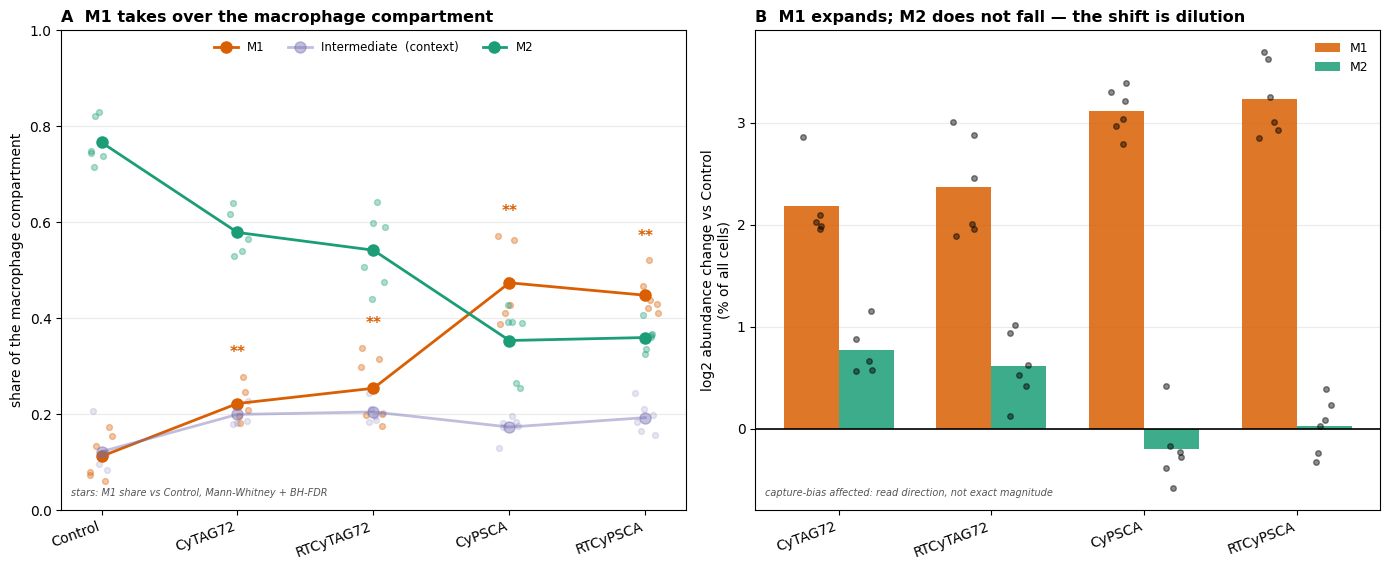


saved -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis/figures/sc_mac_M1_vs_M2_dilution.png


In [13]:
# %% -- 5e. M1 vs M2: dilution or depletion? --
from itertools import combinations
from scipy.stats import mannwhitneyu

M2, M1, INT = "M2_like_Mac", "M1_like_Mac", "Intermediate_Mac"
SUBS = [s for s in [M1, INT, M2] if s in set(obs.loc[obs["is_mac"], "mac_subtype"])]
DISPLAY = {"NoTx": "Control"}
ARMS = [c for c in ["NoTx", "CyTAG72", "RTCyTAG72", "CyPSCA", "RTCyPSCA"] if c in COND_PRESENT]
lab_of = lambda c: DISPLAY.get(c, c)
SUB_C = {M1: "#d95f02", INT: "#7570b3", M2: "#1b9e77"}
short = lambda s: s.replace("_like_Mac", "").replace("_Mac", "")

def bh(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p)
    q = np.empty(n); q[o] = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.clip(q, 0, 1)
star = lambda q: "***" if q < .001 else "**" if q < .01 else "*" if q < .05 else "ns"

# ---------------- per-sample subtype table ----------------
rows = []
for samp, d in obs.groupby("sample", observed=True):
    macs = d[d["is_mac"]]
    if len(macs) < MIN_MACS:
        continue
    m = d.iloc[0]
    rec = {"sample": samp, "cond": str(m["cond"]), "tumor_loc": m["tumor_loc"], "mouse": m["mouse"],
           "n_cells": len(d), "n_mac": len(macs)}
    for s in SUBS:
        n = int((macs["mac_subtype"] == s).sum())
        rec[f"n_{s}"] = n
        rec[f"share_{s}"]     = n / len(macs)        # within macrophages  -> capture-bias ROBUST
        rec[f"pct_cells_{s}"] = 100 * n / len(d)     # of all cells        -> capture-bias AFFECTED
    rows.append(rec)
sub_df = pd.DataFrame(rows)
sub_df.to_csv(OUT_DIR / "sc_mac_subtype_per_sample.csv", index=False)

sub_arm = sub_df.groupby("cond", observed=True)[
    [f"share_{s}" for s in SUBS] + [f"pct_cells_{s}" for s in SUBS]].mean().reindex(ARMS)
print("=== macrophage compartment make-up (mean of per-tumour values) ===")
print(sub_arm.round(3).to_string())

# ---------------- log2 abundance vs Control, tumour-location matched ----------------
lg = sub_df[["sample", "cond", "tumor_loc"]].copy()
for s in SUBS:
    lg[s] = np.log2(sub_df[f"pct_cells_{s}"].where(sub_df[f"pct_cells_{s}"] > 0))
ref = lg[lg["cond"] == NOTX].groupby("tumor_loc", observed=True)[SUBS].mean()
for s in SUBS:
    lg[f"d_{s}"] = [v - ref.loc[t, s] for v, t in zip(lg[s], lg["tumor_loc"])]
lg_t = lg[lg["cond"] != NOTX]
print(f"\n=== log2 change in abundance (% of all cells) vs {NOTX}, tumour-location matched ===")
print(lg_t.groupby("cond", observed=True)[[f"d_{s}" for s in SUBS]].mean()
      .reindex([c for c in ARMS if c != NOTX]).round(3).to_string())
print("  positive = that subtype expanded relative to the untreated baseline.")

# ---------------- stats: each treated arm vs Control, per subtype ----------------
rows = []
for s in (M1, M2):
    r0 = sub_df.loc[sub_df["cond"] == NOTX, f"share_{s}"].values
    fam = []
    for c in [x for x in ARMS if x != NOTX]:
        v = sub_df.loc[sub_df["cond"] == c, f"share_{s}"].values
        U, p = mannwhitneyu(v, r0, alternative="two-sided")
        fam.append({"subtype": s, "arm": c, "share": v.mean(), "share_ctrl": r0.mean(),
                    "cliffs_delta": 2 * U / (len(v) * len(r0)) - 1, "p": p})
    fam = pd.DataFrame(fam); fam["q_BH"] = bh(fam["p"]); fam["sig"] = [star(q) for q in fam["q_BH"]]
    rows.append(fam)
share_stats = pd.concat(rows, ignore_index=True)
share_stats.to_csv(OUT_DIR / "sc_mac_subtype_share_stats_vs_control.csv", index=False)
print(f"\n=== share of macrophage compartment: each arm vs {NOTX} (BH-FDR within each subtype) ===")
print(share_stats.round(4).to_string(index=False))
QS = {(r.subtype, r.arm): r.q_BH for r in share_stats.itertuples()}

# ---------------------------------- figure ----------------------------------
rng4 = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

# ---- A: composition within the macrophage compartment ----
ax = axes[0]
x = np.arange(len(ARMS))
for s in SUBS:
    ax.plot(x, [sub_arm.loc[c, f"share_{s}"] for c in ARMS], "-o", color=SUB_C[s], lw=2, ms=8,
            alpha=1.0 if s in (M1, M2) else 0.45, zorder=3,
            label=f"{short(s)}" + ("" if s in (M1, M2) else "  (context)"))
    for i, c in enumerate(ARMS):
        v = sub_df.loc[sub_df["cond"] == c, f"share_{s}"].values
        ax.scatter(np.repeat(i, len(v)) + rng4.uniform(-.09, .09, len(v)), v, s=18,
                   color=SUB_C[s], alpha=.35 if s in (M1, M2) else .18, zorder=1)
# stars for M1 only (the claim being made); placed above the M1 line
for i, c in enumerate(ARMS):
    if c == NOTX:
        continue
    v = sub_df.loc[sub_df["cond"] == c, f"share_{M1}"].values
    ax.text(i, v.max() + 0.035, star(QS[(M1, c)]), ha="center", va="bottom",
            fontsize=11, color=SUB_C[M1], fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([lab_of(c) for c in ARMS], rotation=20, ha="right", fontsize=10)
ax.set_ylabel("share of the macrophage compartment", fontsize=10); ax.set_ylim(0, 1)
ax.set_title("A  M1 takes over the macrophage compartment", fontsize=11.5, loc="left", fontweight="bold")
ax.legend(fontsize=8.5, frameon=False, loc="upper center", ncol=3)
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
ax.text(0.015, 0.03, f"stars: M1 share vs {lab_of(NOTX)}, Mann-Whitney + BH-FDR",
        transform=ax.transAxes, fontsize=7, style="italic", color="#555")

# ---- B: absolute abundance -> dilution vs depletion ----
ax = axes[1]
treated = [c for c in ARMS if c != NOTX]
w = 0.36
for j, s in enumerate((M1, M2)):
    vals = [lg_t.loc[lg_t["cond"] == c, f"d_{s}"].mean() for c in treated]
    pos = np.arange(len(treated)) + (j - 0.5) * w
    ax.bar(pos, vals, width=w, color=SUB_C[s], alpha=0.85, label=short(s), zorder=2)
    for i, c in enumerate(treated):
        v = lg_t.loc[lg_t["cond"] == c, f"d_{s}"].dropna().values
        ax.scatter(np.repeat(pos[i], len(v)) + rng4.uniform(-.07, .07, len(v)), v,
                   s=16, color="k", alpha=.45, zorder=3)
ax.axhline(0, color="k", lw=1.2, zorder=4)
ax.set_xticks(range(len(treated)))
ax.set_xticklabels([lab_of(c) for c in treated], rotation=20, ha="right", fontsize=10)
ax.set_ylabel(f"log2 abundance change vs {lab_of(NOTX)}\n(% of all cells)", fontsize=10)
ax.set_title("B  M1 expands; M2 does not fall — the shift is dilution",
             fontsize=11.5, loc="left", fontweight="bold")
ax.legend(fontsize=9, frameon=False, loc="upper right")
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
ax.text(0.015, 0.03, "capture-bias affected: read direction, not exact magnitude",
        transform=ax.transAxes, fontsize=7, style="italic", color="#555")

fig.tight_layout()
fig.savefig(FIG_DIR / "sc_mac_M1_vs_M2_dilution.png", dpi=300, bbox_inches="tight")
plt.show(); plt.close(fig)
print("\nsaved ->", FIG_DIR / "sc_mac_M1_vs_M2_dilution.png")


## 6. The abscopal axis — paired within mouse

`X_Tu1_<rep>` and `X_Tu2_<rep>` are the same animal. `n_pairs` counts only mice with **both**
tumours present. Always read each arm against **NoTx**, which is the untreated Tu1/Tu2 baseline.

=== paired within-mouse log2(Tu2 / Tu1) ===
           n_mice  frac_tam_high_n_pairs  mean_sig_n_pairs  frac_tam_high_log2  mean_sig_log2  mac_pct_of_cells_log2  tam_pct_of_cells_log2
cond                                                                                                                                       
NoTx            3                      3                 3              -0.515         -0.592                 -0.364                 -0.879
CyTAG72         3                      2                 2              -0.405         -0.654                 -0.201                 -0.605
CyPSCA          3                      3                 1              -0.523          3.757                  0.142                 -0.381
RTCyTAG72       3                      3                 3              -0.147         -0.398                 -0.125                 -0.272
RTCyPSCA        3                      3                 1               0.048         -0.437                 -0.216

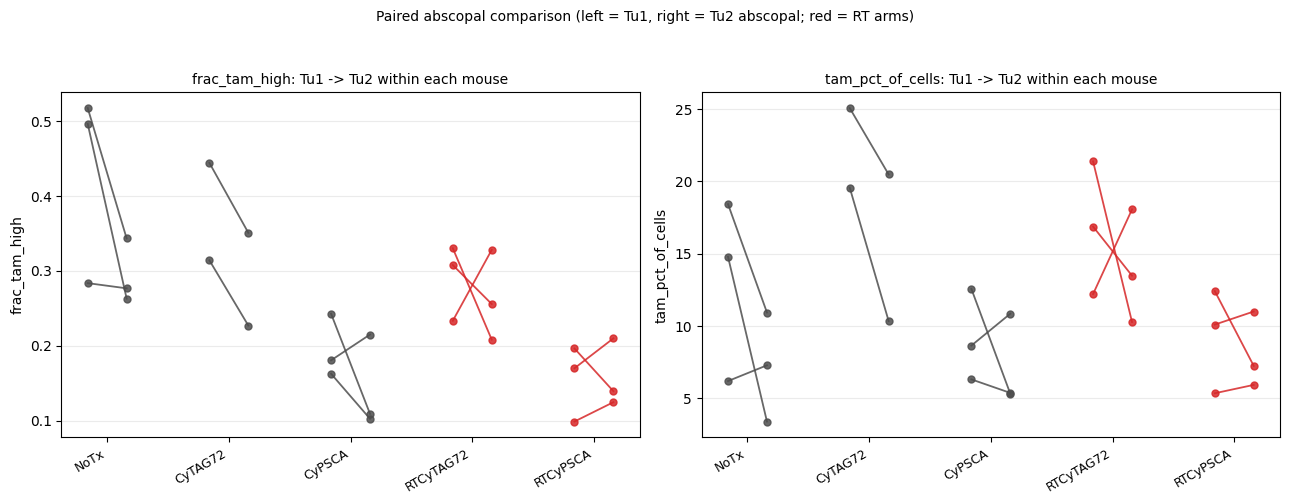

In [21]:
wide = prev.pivot_table(index=["cond", "rep", "mouse"], columns="tumor_loc",
                        values=METRICS, observed=True)
wide.columns = [f"{a}_Tu{b}" for a, b in wide.columns]
wide = wide.reset_index()
for met in METRICS:
    a, b = f"{met}_Tu1", f"{met}_Tu2"
    if a in wide.columns and b in wide.columns:
        wide[f"{met}_log2_Tu2_over_Tu1"] = np.log2(wide[b] / wide[a]).replace([np.inf, -np.inf], np.nan)
wide.to_csv(OUT_DIR / "sc_spp1tam_paired_within_mouse.csv", index=False)

paired = (wide.groupby("cond", observed=True)
          .agg(n_mice=("mouse", "count"),
               **{f"{m}_n_pairs": (f"{m}_log2_Tu2_over_Tu1", "count") for m in STATE_METRICS},
               **{f"{m}_log2": (f"{m}_log2_Tu2_over_Tu1", "mean") for m in METRICS})
          .reindex(COND_PRESENT))
paired.to_csv(OUT_DIR / "sc_spp1tam_paired_summary.csv")
print("=== paired within-mouse log2(Tu2 / Tu1) ===")
print(paired.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, met in zip(axes, ["frac_tam_high", "tam_pct_of_cells"]):
    a, b = f"{met}_Tu1", f"{met}_Tu2"
    present_c = [c for c in COND_PRESENT if c in set(wide["cond"])]
    for i, cnd in enumerate(present_c):
        s = wide[wide["cond"] == cnd]
        for _, r in s.iterrows():
            if np.isfinite(r.get(a, np.nan)) and np.isfinite(r.get(b, np.nan)):
                ax.plot([i - 0.16, i + 0.16], [r[a], r[b]], "-o",
                        color=colors.get(cnd, "k"), ms=5, lw=1.3, alpha=0.85)
    ax.set_xticks(range(len(present_c))); ax.set_xticklabels(present_c, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(met); ax.set_title(f"{met}: Tu1 -> Tu2 within each mouse", fontsize=10)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Paired abscopal comparison (left = Tu1, right = Tu2 abscopal; red = RT arms)",
             y=1.04, fontsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1tam_paired_abscopal.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 7. Treatment contrasts

Built from the arm attributes so one variable moves at a time. n=2-6 per side: **effect sizes and
sign-consistency only**, no p-values.

In [22]:
def contrast(metric, a_groups, b_groups, name, kind):
    a = prev[prev["group"].isin(a_groups)][metric].dropna().values
    b = prev[prev["group"].isin(b_groups)][metric].dropna().values
    if len(a) < 2 or len(b) < 2:
        return None
    out = {"kind": kind, "contrast": name, "metric": metric, "n_a": len(a), "n_b": len(b),
           "mean_a": a.mean(), "mean_b": b.mean(), "diff": a.mean() - b.mean(),
           "log2_ratio": float(np.log2(a.mean() / b.mean())) if a.mean() > 0 and b.mean() > 0 else np.nan}
    if len(a) >= 3 and len(b) >= 3:
        u = mannwhitneyu(a, b, alternative="two-sided")
        out["cliffs_delta"] = 2 * u.statistic / (len(a) * len(b)) - 1
    return out

RT_PAIRS = [(nr, r, cart)
            for cart in sorted({m["cart"] for m in COND_META.values() if m["cart"] != "none"})
            for nr in [c for c in COND_PRESENT if COND_META.get(c, {}).get("RT") is False
                       and COND_META.get(c, {}).get("cart") == cart]
            for r in [c for c in COND_PRESENT if COND_META.get(c, {}).get("RT") is True
                      and COND_META.get(c, {}).get("cart") == cart]]
specs = []
for nr, r, cart in RT_PAIRS:
    specs.append(([f"{r}_Tu2"], [f"{nr}_Tu2"], f"ABSCOPAL  {r}_Tu2 vs {nr}_Tu2  [{cart}]", "abscopal"))
    specs.append(([f"{r}_Tu1"], [f"{nr}_Tu1"], f"DIRECT    {r}_Tu1 vs {nr}_Tu1  [{cart}]", "direct"))
for rt_flag, tag in [(True, "with RT"), (False, "no RT")]:
    psca = [c for c in COND_PRESENT if COND_META.get(c, {}).get("RT") == rt_flag
            and COND_META.get(c, {}).get("cart") == "PSCA"]
    t72 = [c for c in COND_PRESENT if COND_META.get(c, {}).get("RT") == rt_flag
           and COND_META.get(c, {}).get("cart") == "nonspecific"]
    if psca and t72:
        specs.append(([f"{psca[0]}_Tu{t}" for t in (1, 2)], [f"{t72[0]}_Tu{t}" for t in (1, 2)],
                      f"SPECIFICITY  {psca[0]} vs {t72[0]}  [{tag}]", "specificity"))
notx = [c for c in COND_PRESENT if COND_META.get(c, {}).get("cart") == "none"]
for c in [x for x in COND_PRESENT if x not in notx]:
    specs.append(([f"{c}_Tu{t}" for t in (1, 2)], [f"{notx[0]}_Tu{t}" for t in (1, 2)],
                  f"vs UNTREATED  {c} vs {notx[0]}", "vs_untreated"))

rows = [r for met in METRICS for a, b, nm, kind in specs if (r := contrast(met, a, b, nm, kind))]
contrasts = pd.DataFrame(rows)
contrasts.to_csv(OUT_DIR / "sc_spp1tam_prevalence_contrasts.csv", index=False)
for kind in ["specificity", "abscopal", "direct", "vs_untreated"]:
    sub = contrasts[(contrasts["kind"] == kind) & (contrasts["metric"].isin(STATE_METRICS))]
    if sub.empty:
        continue
    print(f"\n=== {kind.upper()} (state metrics) ===")
    print(sub[["contrast", "metric", "n_a", "n_b", "mean_a", "mean_b", "log2_ratio"]]
          .round(3).to_string(index=False))


=== SPECIFICITY (state metrics) ===
                                     contrast        metric  n_a  n_b  mean_a  mean_b  log2_ratio
SPECIFICITY  RTCyPSCA vs RTCyTAG72  [with RT] frac_tam_high    6    6   0.156   0.277      -0.825
      SPECIFICITY  CyPSCA vs CyTAG72  [no RT] frac_tam_high    6    5   0.169   0.319      -0.919
SPECIFICITY  RTCyPSCA vs RTCyTAG72  [with RT]      mean_sig    6    6  -0.011   0.112         NaN
      SPECIFICITY  CyPSCA vs CyTAG72  [no RT]      mean_sig    6    5  -0.020   0.158         NaN

=== ABSCOPAL (state metrics) ===
                                             contrast        metric  n_a  n_b  mean_a  mean_b  log2_ratio
         ABSCOPAL  RTCyPSCA_Tu2 vs CyPSCA_Tu2  [PSCA] frac_tam_high    3    3   0.158   0.142       0.152
ABSCOPAL  RTCyTAG72_Tu2 vs CyTAG72_Tu2  [nonspecific] frac_tam_high    3    3   0.264   0.279      -0.080
         ABSCOPAL  RTCyPSCA_Tu2 vs CyPSCA_Tu2  [PSCA]      mean_sig    3    3  -0.013  -0.043         NaN
ABSCOPAL  RTCyT

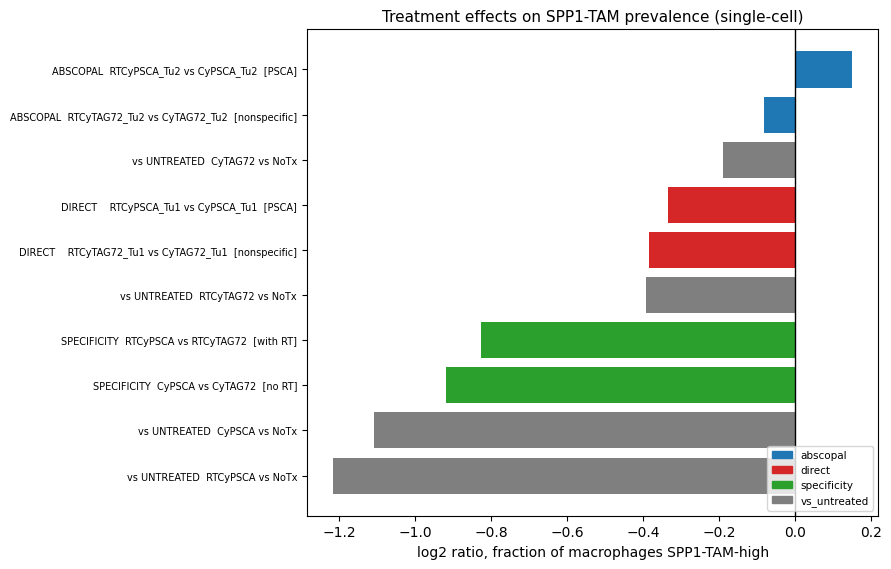

In [23]:
plot = contrasts[contrasts["metric"] == "frac_tam_high"].dropna(subset=["log2_ratio"]).sort_values("log2_ratio")
if not plot.empty:
    kind_c = {"abscopal": "#1f77b4", "direct": "#d62728", "specificity": "#2ca02c", "vs_untreated": "#7f7f7f"}
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(plot) + 1.6))
    ax.barh(range(len(plot)), plot["log2_ratio"].values,
            color=[kind_c.get(k, "#999") for k in plot["kind"]])
    ax.axvline(0, color="k", lw=1)
    ax.set_yticks(range(len(plot))); ax.set_yticklabels(plot["contrast"], fontsize=7)
    ax.set_xlabel("log2 ratio, fraction of macrophages SPP1-TAM-high")
    ax.set_title("Treatment effects on SPP1-TAM prevalence (single-cell)", fontsize=11)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=c, label=k) for k, c in kind_c.items()], fontsize=7.5, loc="lower right")
    fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1tam_prevalence_contrasts.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 8. Sensitivity — signature vs raw Spp1

The signature is the defensible definition (multi-gene, spillover-tested, treatment-blind). Raw
`Spp1` is the naive one. If the arm ordering agrees, the prevalence result does not depend on
which definition you pick — which is the useful thing to be able to say.

In [24]:
comp = by_cond[["frac_tam_high", "frac_spp1_high_raw"]].copy()
comp.columns = ["signature_based", "raw_Spp1_based"]
comp["rank_sig"] = comp["signature_based"].rank(ascending=False)
comp["rank_raw"] = comp["raw_Spp1_based"].rank(ascending=False)
print("=== fraction of macrophages 'high', by definition, per arm ===")
print(comp.round(3).to_string())
r_s = comp[["signature_based", "raw_Spp1_based"]].corr(method="spearman").iloc[0, 1]
print(f"\nSpearman between the two definitions across arms: {r_s:+.3f}")
print("  high positive -> the prevalence ordering is definition-independent (report it).")
print("  low/negative  -> the two definitions disagree; lead with the signature and say why.")

=== fraction of macrophages 'high', by definition, per arm ===
           signature_based  raw_Spp1_based  rank_sig  rank_raw
cond                                                          
NoTx                 0.363           0.677       1.0       1.0
CyTAG72              0.319           0.328       2.0       2.0
CyPSCA               0.169           0.178       4.0       4.0
RTCyTAG72            0.277           0.305       3.0       3.0
RTCyPSCA             0.156           0.160       5.0       5.0

Spearman between the two definitions across arms: +1.000
  high positive -> the prevalence ordering is definition-independent (report it).
  low/negative  -> the two definitions disagree; lead with the signature and say why.


## 9. Summary

In [ ]:
print(f"""
==================== SUMMARY — report these back ====================
Samples / mice : {len(prev)} / {prev['mouse'].nunique()}   arms: {COND_PRESENT}
Signature      : {len(present)}/{len(sig_genes)} genes | GLOBAL SPP1-TAM-high cut = {SIG_CUT:.4f}
                 (top {int((1-TAM_HIGH_Q)*100)}% of pooled macrophages; {int(obs['tam_high'].sum()):,} cells)

Prevalence by arm:
{by_cond[['n_samples','frac_tam_high','mean_sig','mac_pct_of_cells','tam_pct_of_cells']].round(3).to_string()}

Decomposition vs NoTx (log2):
{decomp[['group','log2_recruitment','log2_state','log2_burden','driver']].round(3).to_string(index=False)}

HOW TO READ THIS
 1. frac_tam_high is THE metric: the share of macrophages carrying the SPP1-TAM program. It is a
    within-compartment proportion, so single-cell dissociation bias does NOT distort it. The
    abundance metrics (mac_pct_of_cells, tam_pct_of_cells) DO inherit that bias - quote them with
    the caveat, or quote frac_tam_high alone.
 2. §4 separates recruitment from state. 06 found spatially that treatment changes how MANY
    SPP1-TAMs there are far more than how strong each one is; check whether single-cell agrees.
 3. §7 SPECIFICITY (PSCA vs TAG72) is the CAR-T-attributable contrast. 05 found ~40% lower Spp1
    and 06 found ~2.9x lower TAM density; a third agreeing readout here would be strong.
 4. §8 says whether any of this depends on using the signature rather than raw Spp1.

WHY THIS NOTEBOOK EXISTS: 01c splits Spp1 WITHIN each sample, which fixes the treatment confound
but forces ~25% of macrophages to be 'high' in every arm. Prevalence needs the GLOBAL cut used
here. The signature is usable for this precisely because it was derived treatment-blind.

CAVEAT: n=2-3 samples per arm; effect sizes and sign-consistency only, no p-values.
=====================================================================
""")